<a href="https://colab.research.google.com/github/imriyamandal/Learning-ML/blob/main/Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv('cuisines.csv')

In [7]:
df.head()

,Unnamed: 0,cuisine,almond,angelica,anise,anise_seed,apple,apple_brandy,apricot,armagnac,...,whiskey,white_bread,white_wine,whole_grain_wheat_flour,wine,wood,yam,yeast,yogurt,zucchini
0,65,indian,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,66,indian,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,67,indian,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,68,indian,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,69,indian,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2448 entries, 0 to 2447
Columns: 385 entries, Unnamed: 0 to zucchini
dtypes: int64(384), object(1)
memory usage: 7.2+ MB


<Axes: ylabel='cuisine'>

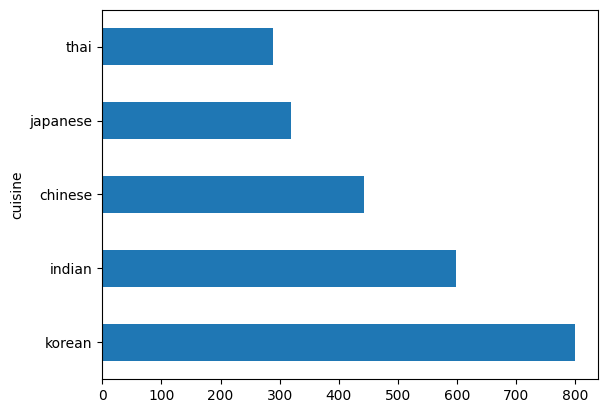

In [10]:
df.cuisine.value_counts().plot.barh()

In [12]:
thai_df = df[df.cuisine == 'thai']
japanese_df = df[df.cuisine == 'japanese']
chinese_df = df[df.cuisine == 'chinese']
indian_df = df[df.cuisine == 'indian']
korean_df = df[df.cuisine == 'korean']

In [13]:
print(f'thai df : {thai_df.shape}')
print(f'japanese df : {japanese_df.shape}')
print(f'chinese df : {chinese_df.shape}')
print(f'indian df : {indian_df.shape}')
print(f'korean df : {korean_df.shape}')

thai df : (289, 385)
japanese df : (320, 385)
chinese df : (442, 385)
indian df : (598, 385)
korean df : (799, 385)


In [14]:
def create_ingredient_df(df):
  ingredient_df = df.T.drop(['cuisine', 'Unnamed: 0']).sum(axis=1).to_frame('value')
  ingredient_df = ingredient_df[(ingredient_df.T != 0).any()]
  ingredient_df = ingredient_df.sort_values(by='value', ascending=False, inplace=False)

  return ingredient_df


<Axes: >

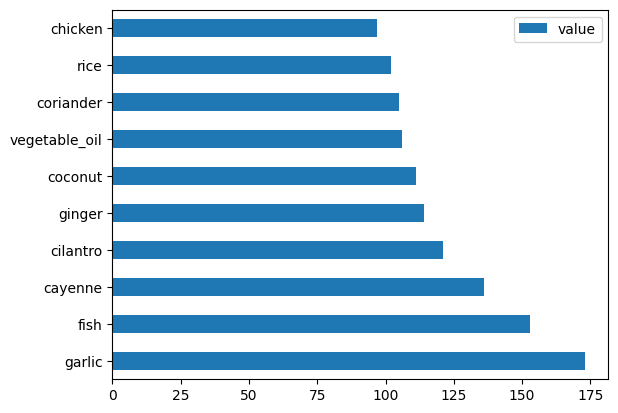

In [15]:
thai_ingredient_df = create_ingredient_df(thai_df)
thai_ingredient_df.head(10).plot.barh()

<Axes: >

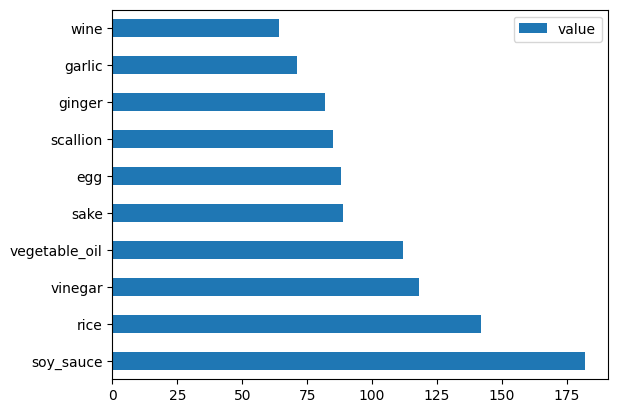

In [17]:
japanese_ingredient_df = create_ingredient_df(japanese_df)
japanese_ingredient_df.head(10).plot.barh()

<Axes: >

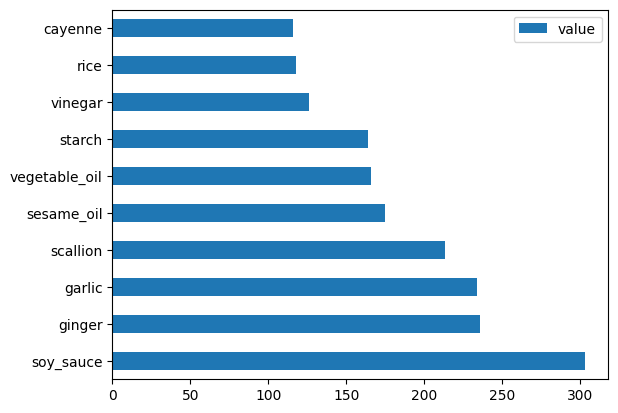

In [18]:
chinese_ingredient_df = create_ingredient_df(chinese_df)
chinese_ingredient_df.head(10).plot.barh()

<Axes: >

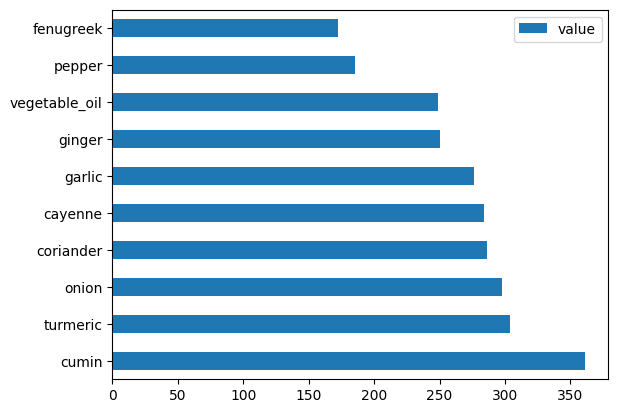

In [19]:
indian_ingredient_df = create_ingredient_df(indian_df)
indian_ingredient_df.head(10).plot.barh()

<Axes: >

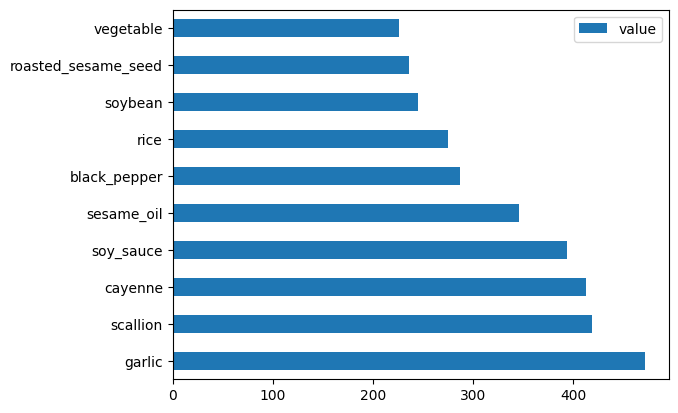

In [20]:
korean_ingredient_df = create_ingredient_df(korean_df)
korean_ingredient_df.head(10).plot.barh()

In [21]:
feature_df =df.drop(['cuisine', 'Unnamed: 0', 'rice', 'garlic', 'ginger'], axis=1)
labels_df = df.cuisine
feature_df.head()

,almond,angelica,anise,anise_seed,apple,apple_brandy,apricot,armagnac,artemisia,artichoke,...,whiskey,white_bread,white_wine,whole_grain_wheat_flour,wine,wood,yam,yeast,yogurt,zucchini
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


SMOTE : to balace the imbalanced dataset


In [22]:
from imblearn.over_sampling import SMOTE
oversample = SMOTE()
transformed_feature_df, transformed_labels_df = oversample.fit_resample(feature_df, labels_df)


In [23]:
print(f' new label count  : {transformed_labels_df.value_counts()}')
print(f' old label count : {labels_df.value_counts()}')

 new label count  : cuisine
indian      799
thai        799
chinese     799
japanese    799
korean      799
Name: count, dtype: int64
 old label count : cuisine
korean      799
indian      598
chinese     442
japanese    320
thai        289
Name: count, dtype: int64


In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report

In [26]:
X_train, X_test, y_train, y_test = train_test_split(transformed_feature_df, transformed_labels_df, test_size=0.3)

In [28]:
lr = LogisticRegression(multi_class = 'ovr', solver='liblinear')
model = lr.fit(X_train, np.ravel(y_train))

accuracy = model.score(X_test, y_test)
print("Accuracy is {}".format(accuracy))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy is 0.804837364470392


In [31]:
print(f'ingredients : {X_test.iloc[50][X_test.iloc[50]!= 0].keys()}')
print(f'cuisine : {y_test.iloc[50]}')

ingredients : Index(['scallion', 'soy_sauce', 'vegetable_oil', 'vinegar'], dtype='object')
cuisine : japanese


In [33]:
test = X_test.iloc[50].values.reshape(-1, 1).T
proba = model.predict_proba(test)
classes = model.classes_
resultdf = pd.DataFrame(data=proba, columns=classes)

toppred = resultdf.T.sort_values(by=0, ascending=False)
toppred.head()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


,0
japanese,0.480273
chinese,0.449311
korean,0.040878
thai,0.027022
indian,0.002516


In [34]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

     chinese       0.75      0.71      0.73       245
      indian       0.92      0.89      0.90       227
    japanese       0.77      0.78      0.77       240
      korean       0.83      0.81      0.82       234
        thai       0.77      0.84      0.81       253

    accuracy                           0.80      1199
   macro avg       0.81      0.81      0.81      1199
weighted avg       0.81      0.80      0.80      1199

